# EP01 — MLP Debugging & Training Issues
**Exam Relevance:** 2025 Q1, 2024 Q3

This notebook covers the most common MLP failure modes that appear repeatedly in exams:
- Zero initialization (symmetry problem)
- Optimizer choice (Adam vs SGD)
- Learning rate too low
- Activation functions (ReLU, dying ReLU, alternatives)
- Underfitting diagnosis (low train + low val accuracy)

---

## 1. The Symmetry Problem — Why Zero Init Kills Learning

**2025 Q1 asked:** *"The weights and biases are initialized to 0 — is this a problem?"*

**Answer:** YES. This is the **symmetry problem**.
- All neurons in a layer compute identical outputs
- Gradients are identical → all neurons update identically
- No neuron specialises → the network effectively has 1 neuron per layer

**Fix:** Random initialisation (Xavier/He init)

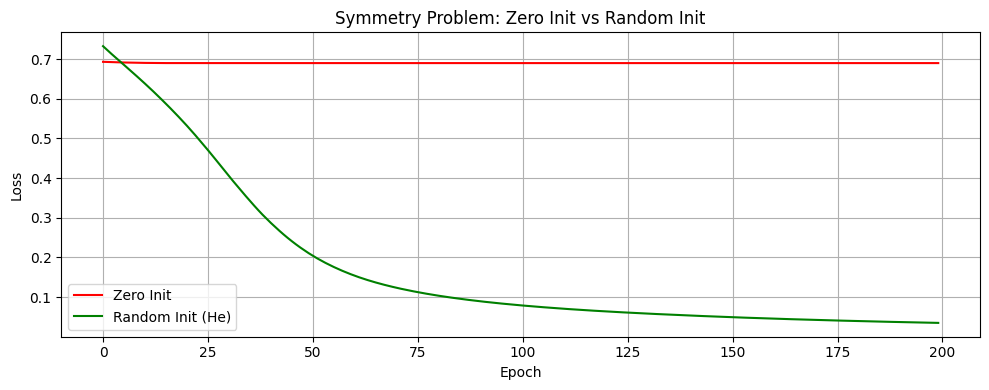

Zero init final loss:   0.6899
Random init final loss: 0.0350


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Demonstrate symmetry problem vs random init
torch.manual_seed(42)

X = torch.randn(100, 4)
y = (X[:, 0] + X[:, 1] > 0).float().unsqueeze(1)

def make_mlp_zero_init():
    model = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    # Force zero initialization
    for layer in model:
        if isinstance(layer, nn.Linear):
            nn.init.zeros_(layer.weight)
            nn.init.zeros_(layer.bias)
    return model

def make_mlp_random_init():
    model = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    # Default PyTorch init (Kaiming uniform) — already applied
    return model

def train(model, label):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    losses = []
    for epoch in range(200):
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

loss_zero = train(make_mlp_zero_init(), 'Zero Init')
loss_random = train(make_mlp_random_init(), 'Random Init')

plt.figure(figsize=(10, 4))
plt.plot(loss_zero, label='Zero Init', color='red')
plt.plot(loss_random, label='Random Init (He)', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Symmetry Problem: Zero Init vs Random Init')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Zero init final loss:   {loss_zero[-1]:.4f}")
print(f"Random init final loss: {loss_random[-1]:.4f}")

## 2. Learning Rate — The Most Common Hyperparameter Mistake

**2025 Q1 asked:** *"Learning rate = 1e-6 — is this a problem?"*

**Answer:** YES. Too small a learning rate means:
- Gradient steps are tiny → loss decreases extremely slowly
- Loss plateaus early because updates are negligible
- Training feels "stuck" even though the model isn't converged

**Typical good LR range:** 1e-4 to 1e-2 for Adam

In [ ]:
learning_rates = [1e-6, 1e-4, 1e-2, 0.1]
colors = ['red', 'orange', 'green', 'purple']

plt.figure(figsize=(12, 5))
for lr, color in zip(learning_rates, colors):
    model = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    losses = []
    for epoch in range(300):
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    plt.plot(losses, label=f'LR={lr}', color=color)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Effect of Learning Rate on Training (Adam optimizer)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Notice: LR=1e-6 barely moves. LR=1e-2 converges fastest.")

## 3. Adam vs SGD — Why Adam is NOT the problem

**2025 Q1 asked:** *"Optimizer used is Adam — is this contributing to poor performance?"*

**Answer:** NO. Adam is generally a good default optimizer.
- Adam adapts the learning rate per parameter using momentum estimates
- It's more robust to poor LR choices than vanilla SGD
- The problem in Q1 is the LR=1e-6 and zero init — NOT Adam itself

**Key point for exam:** Identify the *actual* culprit (zero init + tiny LR), not the red herring (Adam).

## 4. ReLU Activation — Advantage and the Dying ReLU Problem

**2025 Q1 asked:** *"Activation is ReLU — is this contributing to poor performance?"*

**Answer:** ReLU is generally fine, BUT it can contribute if combined with bad init:
- **Dying ReLU:** If weights push pre-activations to always be negative, those neurons output 0 forever (gradient = 0 → neuron never recovers)
- With zero init specifically, ReLU outputs 0 for everything initially

**Fixes:** Leaky ReLU, ELU, or He initialisation

In [ ]:
# Visualise different activation functions
x = np.linspace(-4, 4, 200)

activations = {
    'ReLU':       np.maximum(0, x),
    'Leaky ReLU': np.where(x >= 0, x, 0.1 * x),
    'ELU':        np.where(x >= 0, x, np.exp(x) - 1),
    'Sigmoid':    1 / (1 + np.exp(-x)),
    'Tanh':       np.tanh(x),
}

fig, axes = plt.subplots(1, len(activations), figsize=(16, 3))
for ax, (name, vals) in zip(axes, activations.items()):
    ax.plot(x, vals, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(name)
    ax.set_ylim(-2, 4)
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions — Note how ReLU is zero for all x<0 (dying neuron risk)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Underfitting Diagnosis (2024 Q3)

**Scenario:** Train acc = 40%, Val acc = 38%  
This is **underfitting** — the model isn't even learning the training data well.

| Suggestion | Effect | Why |
|---|---|---|
| Train 500 epochs | Train acc ↑, Val acc ↑ | Model hasn't converged yet — more time helps |
| Early stopping | Minimal help here | Early stopping helps overfitting, not underfitting |
| 10 hidden layers | Could help OR hurt | More capacity, but also risk of vanishing gradients without proper init/BN |

In [ ]:
# Demonstrate underfitting vs good fit vs overfitting
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X_np, y_np = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(X_np, y_np, test_size=0.3, random_state=42)

X_tr = torch.FloatTensor(X_train_np)
y_tr = torch.FloatTensor(y_train_np).unsqueeze(1)
X_vl = torch.FloatTensor(X_val_np)
y_vl = torch.FloatTensor(y_val_np).unsqueeze(1)

def train_and_track(model, epochs=500):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.BCELoss()
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl), y_vl).item()
        val_losses.append(val_loss)
    return train_losses, val_losses

# Underfit: too few neurons
underfit = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 1), nn.Sigmoid())
# Good fit
goodfit  = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
# Overfit: massive model + less data
overfit  = nn.Sequential(nn.Linear(2, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1), nn.Sigmoid())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model, title in zip(axes, [underfit, goodfit, overfit], ['Underfit', 'Good Fit', 'Overfit']):
    tr, vl = train_and_track(model)
    ax.plot(tr, label='Train loss')
    ax.plot(vl, label='Val loss')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Underfit: both losses stay high")
print("Good Fit: both losses decrease together")
print("Overfit:  train loss drops but val loss rises")

## Exam Quick-Reference Summary

| Issue | Symptom | Fix |
|---|---|---|
| Zero init | Loss stuck from epoch 1 | Xavier / He random init |
| LR too small (1e-6) | Loss decreases but agonisingly slowly | Use LR ~1e-3 to 1e-2 with Adam |
| Dying ReLU | Neurons output 0, gradients vanish | Leaky ReLU, ELU, or proper init |
| Underfitting | Low train AND val accuracy | More epochs, more capacity, better LR |
| Overfitting | High train, low val accuracy | Dropout, L2 reg, early stopping, more data |

**Adam is rarely the problem** — it's one of the best general-purpose optimizers.